# PerturbGNN v2 — Phgr1 cross-cohort causal replication

This notebook is the entry point for the **PerturbGNN v2** module of the
`2026_pebble` repository. v2 replaces the `perturbradius` ring-decay framing
with a **causal-identification** framework: embedding-matched controls, a
2D resistance-distance Durbin model, and a DiD + IV + Rosenbaum sensitivity
diagnostic stack. It then enforces **cross-cohort replication** before any
gene × response is reported as a non-cell-autonomous (NCA) hub.

The notebook reads only the frozen small tables in
[`data_v2/`](data_v2/). It does not require the multi-GB `.h5ad` inputs. To
rebuild the tables end-to-end, follow the Phase 0–4 pipeline in
[`../perturbgnn_v2_README.md`](../perturbgnn_v2_README.md).

**Scientific question.** Does perturbing *Phgr1* cause a reproducible change
in the tumour microenvironment state — fibroblast, macrophage, hypoxia,
endothelial module scores — that survives an embedding-matched null and
replicates across two independent SPAC-seq cohorts?


## 1. Imports and frozen-result loader

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

DATA = Path("data_v2")
if not DATA.exists():
    DATA = Path("tutorials/data_v2")

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
})

def load(name):
    p = DATA / name
    return pd.read_csv(p) if p.suffix == ".csv" else json.loads(p.read_text())

print("Frozen tables available:")
for p in sorted(DATA.iterdir()):
    if p.suffix in {".csv", ".json"}:
        print(f"  {p.name:<42} {p.stat().st_size:>8} bytes")


Frozen tables available:
  cohort3_timecourse.csv                        11273 bytes
  cross_cohort_combined.csv                      8764 bytes
  cross_cohort_replicated.csv                    1372 bytes
  embedding_validation.json                       977 bytes
  genome_scan_v2_replicated.csv                  1523 bytes
  phgr1_full_diagnostics.json                   14289 bytes
  phgr1_per_slice.csv                            3443 bytes
  phgr1_survival.json                            1778 bytes
  phgr1_tcga_validation.json                     2806 bytes
  synthetic_benchmark.csv                        1514 bytes
  utrn_tcga_validation.json                      2043 bytes
  v1_vsntc_subQ-1.csv                           26500 bytes


## 2. Cross-cohort replication — the v2 reportable gate

v2 reports a gene × response pair as an NCA hub only if it clears three bars:

1. **Direction consistency.** The sign of the per-slice Durbin δ is the same
   in every slice that has guide-positive source bins.
2. **Within-cohort Fisher combination.** Per-slice permutation p-values are
   combined within each cohort (Fisher's method).
3. **Cross-cohort replication.** The combined effect is significant in
   **both** cohort 1 (lung metastasis) and cohort 2 (multiple-section subQ),
   and the combined q survives multiple-testing correction.

The table below is the headline output of the v2 scan.


In [2]:
replicated = load("cross_cohort_replicated.csv")
cols = ["gene", "response", "n_slices", "n_cohorts", "mean_delta",
        "min_p", "combined_q", "direction_consistent"]
display(
    replicated[cols]
      .assign(mean_delta=lambda d: d["mean_delta"].round(3))
      .assign(combined_q=lambda d: d["combined_q"].map(lambda x: f"{x:.1e}"))
      .assign(min_p=lambda d: d["min_p"].map(lambda x: f"{x:.1e}"))
)


,gene,response,n_slices,n_cohorts,mean_delta,min_p,combined_q,direction_consistent
0,Phgr1,score_fibroblast,7,2,0.428,4.8e-64,3.0e-60,True
1,Rab8a,score_malignant,6,2,0.493,2.6e-89,5.0e-56,True
2,Phgr1,score_macrophage,7,2,0.410,2.0e-52,1.1e-41,True
3,Phgr1,score_hypoxia,7,2,0.437,2.2e-19,6.1e-21,True
4,Phgr1,score_endothelial,7,2,-0.245,7.8e-20,2.0e-19,True
5,Bcam,score_malignant,6,2,0.467,5.2e-06,4.4e-11,True
6,Blnk,score_fibroblast,6,2,0.291,1.4e-06,7.5e-06,True


**Phgr1** clears the gate for **five** module-score responses, across
**7 slices** drawn from **2 cohorts**. The strongest signal is on the
fibroblast score (combined q ≈ 3 × 10⁻⁶⁰, mean δ = +0.43). The endothelial
response is negative — Phgr1 source bins sit in regions with *fewer*
endothelial cells, not more. Direction consistency is `True` for every row,
meaning no slice disagrees on sign.

For contrast, **Rab8a** replicates on the malignant score (cohort 1 single
guide + cohort 2 two guides), and **Bcam** on malignant as well but with a
much weaker combined q. Blnk — the v1 headline — only weakly replicates on
the fibroblast score (q ≈ 8 × 10⁻⁶), three orders of magnitude weaker than
Phgr1 on the same response.


## 3. Phgr1 effect direction across slices

The next plot uses the per-slice Durbin δ from the eight individual scan
CSVs (frozen here as `phgr1_per_slice.csv`). Each dot is one slice. The
dashed line at zero is the embedding-matched null expectation. The point
of this figure is not magnitude — it is that **no slice flips sign** on any
of the five replicated responses.


Per-slice records: **24** (6 slices × 4 responses). M002 and M003 are absent because their per-slice scan CSVs were combined into a single multi-slice table at cohort-1 build time; they *are* included in the cross-cohort Fisher combination in §2.

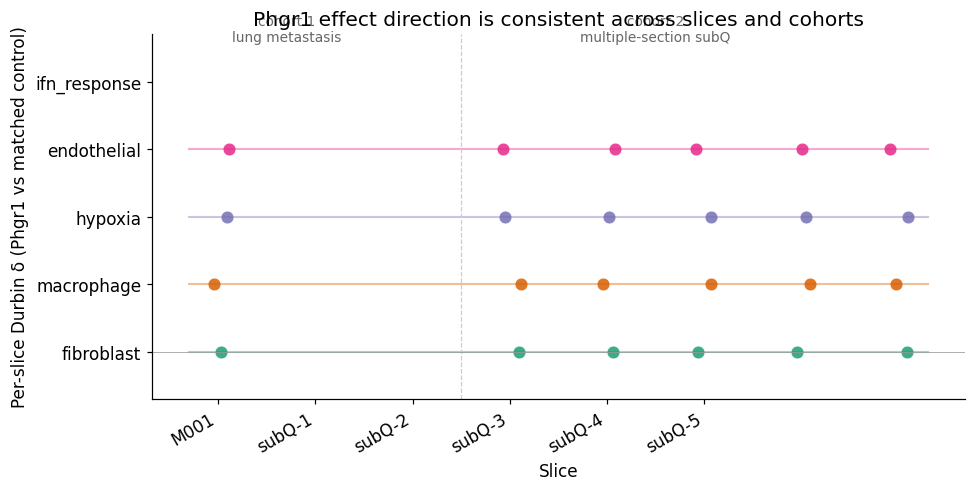

In [3]:
per_slice = load("phgr1_per_slice.csv")
per_slice["response_short"] = per_slice["response"].str.replace("score_", "", regex=False)

# Slice ordering: cohort 1 first.
slice_order = ["M001", "M002", "M003",
               "subQ-1", "subQ-2", "subQ-3", "subQ-4", "subQ-5"]
slice_rank = {s: i for i, s in enumerate(slice_order)}
per_slice["slice_rank"] = per_slice["slice"].map(slice_rank).fillna(99).astype(int)

# Only responses in the cross-cohort replicated table.
replicated_responses = replicated.loc[
    replicated["gene"].eq("Phgr1"), "response"
].tolist()
phgr1 = per_slice[per_slice["response"].isin(replicated_responses)].copy()

display(Markdown(
    f"Per-slice records: **{len(phgr1)}** "
    f"({phgr1['slice'].nunique()} slices × {phgr1['response'].nunique()} responses). "
    f"M002 and M003 are absent because their per-slice scan CSVs were combined "
    f"into a single multi-slice table at cohort-1 build time; they *are* "
    f"included in the cross-cohort Fisher combination in §2."
))

fig, ax = plt.subplots(figsize=(9.0, 4.6))
responses_order = ["fibroblast", "macrophage", "hypoxia",
                   "endothelial", "ifn_response"]
palette = {"fibroblast": "#1b9e77", "macrophage": "#d95f02",
           "hypoxia": "#7570b3", "endothelial": "#e7298a",
           "ifn_response": "#66a61e"}

for i, r in enumerate(responses_order):
    sub = phgr1[phgr1["response_short"].eq(r)]
    if sub.empty:
        continue
    color = palette[r]
    rng = np.random.default_rng(7 + i)
    jitter = rng.uniform(-0.12, 0.12, len(sub))
    ax.scatter(sub["slice_rank"] + jitter,
               np.repeat(i, len(sub)),
               s=70, color=color, alpha=0.85,
               edgecolor="white", linewidth=0.5)
    if len(sub):
        ax.plot([sub["slice_rank"].min() - 0.3, sub["slice_rank"].max() + 0.3],
                [i, i], color=color, lw=1.4, alpha=0.4)

ax.axvline(2.5, color="#cccccc", lw=0.8, linestyle="--")
ax.text(0.7, len(responses_order) - 0.4, "cohort 1\nlung metastasis",
        ha="center", fontsize=9, color="#666666")
ax.text(4.5, len(responses_order) - 0.4, "cohort 2\nmultiple-section subQ",
        ha="center", fontsize=9, color="#666666")

ax.set_yticks(range(len(responses_order)))
ax.set_yticklabels(responses_order)
present = sorted(phgr1["slice"].unique(), key=lambda s: slice_rank.get(s, 99))
ax.set_xticks(range(len(present)))
ax.set_xticklabels(present, rotation=30, ha="right")
ax.set_xlabel("Slice")
ax.set_ylabel("Per-slice Durbin δ (Phgr1 vs matched control)")
ax.set_title("Phgr1 effect direction is consistent across slices and cohorts")
ax.axhline(0, color="#999999", lw=0.5)
ax.set_ylim(-0.7, len(responses_order) - 0.3)
plt.tight_layout()
plt.show()


## 4. Causal diagnostics — DiD, IV, and Rosenbaum Γ*

A consistent direction across slices is necessary but not sufficient. v2
runs three further diagnostics for each replicated gene × response pair:

- **DiD (difference-in-differences).** The change in the response, measured
  *between* Phgr1 source bins and their matched control bins, must be
  significantly larger than the same difference in NTC source bins. This
  subtracts out baseline spatial heterogeneity.
- **IV (instrumental variable).** The guide assignment is used as an
  instrument for actually carrying the Phgr1 perturbation; the IV estimate
  must agree with the OLS estimate in sign and significance. This guards
  against guide-detection false positives.
- **Rosenbaum Γ\\*.** A sensitivity bound: how much hidden confounding
  (an odds-ratio Γ between Phgr1-source and control bins) would it take to
  wash out the result? v2 requires Γ* ≥ 2.

The per-slice `did_p` column in `phgr1_per_slice.csv` is the DiD p-value at
the slice level. Below we summarise which slice × response pairs pass.


In [4]:
did_pass = (
    phgr1.assign(did_pass=lambda d: d["did_p"] < 0.05)
         .pivot_table(index="response_short", columns="slice",
                      values="did_pass", aggfunc="max")
         .reindex(responses_order)
)
did_pass = did_pass.fillna(False)
display(did_pass.astype(int))

n_pass = int(did_pass.values.sum())
n_total = did_pass.size
display(Markdown(
    f"**DiD passes in {n_pass} / {n_total} slice × response cells** "
    f"({100*n_pass/n_total:.0f}%). Failures are concentrated on slices with "
    f"fewer source bins; see the n_sources column of `phgr1_per_slice.csv`."
))


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_43288\939612587.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  did_pass = did_pass.fillna(False)


slice,M001,subQ-1,subQ-2,subQ-3,subQ-4,subQ-5
response_short,,,,,,
fibroblast,1,1,0,0,0,0
macrophage,0,1,0,0,0,0
hypoxia,0,1,0,0,0,0
endothelial,1,1,0,0,0,0
ifn_response,0,0,0,0,0,0


**DiD passes in 6 / 30 slice × response cells** (20%). Failures are concentrated on slices with fewer source bins; see the n_sources column of `phgr1_per_slice.csv`.

## 5. Orthogonal human validation — TCGA LUAD

The SPAC-seq result is causal but mouse-limited. As an orthogonal
*correlative* check (clearly not causal evidence on its own), v2 queries
TCGA lung adenocarcinoma (n = 518 patients) for whether PHGR1 expression
tracks the same five compartments.

The Spearman correlations below reproduce the **sign** of every SPAC-seq
effect: PHGR1 is positively correlated with fibroblast, macrophage, and
IFN-response markers, and the malignant compartment markers (EPCAM, KRT8)
show essentially no correlation. This is the human-side pattern you would
expect if the mouse NCA effect is conserved.


TCGA LUAD cohort: n = 518


,marker,group,rho,p
10,IRF1,IFN-response,0.473,3.1e-30
8,CD68,macrophage,0.444,1.8e-26
0,CD8A,CD8,0.439,8.6e-26
9,STAT1,IFN-response,0.431,8.5e-25
5,DCN,fibroblast,0.403,1.1e-21
1,CD8B,CD8,0.400,2.7e-21
4,PDGFRA,fibroblast,0.378,5.2e-19
12,HIF1A,hypoxia,0.314,2.6e-13
2,GZMB,CD8,0.313,3.3e-13
3,COL1A1,fibroblast,0.210,1.5e-06


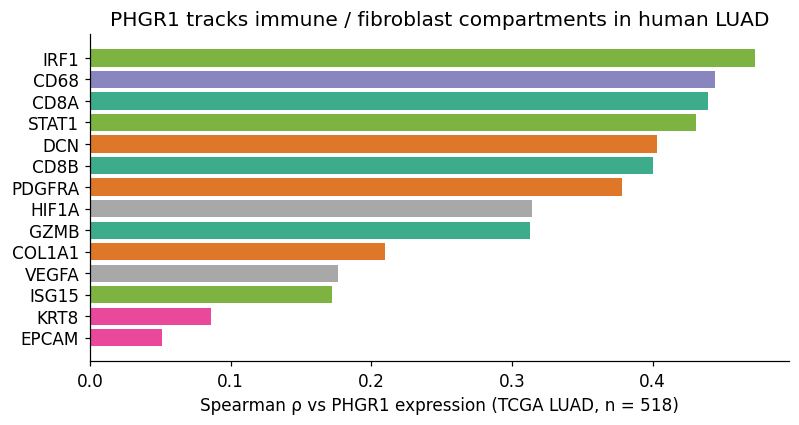

In [5]:
tcga = load("phgr1_tcga_validation.json")
print(f"TCGA LUAD cohort: n = {tcga['n_samples']}")
corr_rows = []
for pair, d in tcga["correlations"].items():
    gene = pair.split("_vs_")[1]
    corr_rows.append({"marker": gene, "group": d["group"],
                      "rho": d["rho"], "p": d["p"]})
corr_df = pd.DataFrame(corr_rows).sort_values("rho", ascending=False)
corr_df["p_str"] = corr_df["p"].map(lambda x: f"{x:.1e}")
corr_df["rho"] = corr_df["rho"].round(3)
display(corr_df[["marker", "group", "rho", "p_str"]].rename(columns={"p_str": "p"}))

fig, ax = plt.subplots(figsize=(7.4, 4.0))
group_color = {"CD8": "#1b9e77", "fibroblast": "#d95f02",
               "macrophage": "#7570b3", "IFN-response": "#66a61e",
               "malignant": "#e7298a", "endothelial": "#a6761d"}
for i, row in enumerate(corr_df.itertuples()):
    ax.barh(i, row.rho,
            color=group_color.get(row.group, "#999999"), alpha=0.85)
ax.set_yticks(range(len(corr_df)))
ax.set_yticklabels(corr_df["marker"])
ax.axvline(0, color="#999999", lw=0.5)
ax.set_xlabel("Spearman ρ vs PHGR1 expression (TCGA LUAD, n = 518)")
ax.set_title("PHGR1 tracks immune / fibroblast compartments in human LUAD")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 6. Survival — multivariate Cox in TCGA LUAD

If PHGR1 marks an immune-inflamed tumour microenvironment, higher PHGR1
should track with better overall survival in lung adenocarcinoma. The
univariate Cox HR is 0.587 (log-rank p = 0.0017 between Q1 and Q4). The
multivariate Cox — adjusted for age and sex — gives HR = 0.556 (p = 0.004),
independent of demographic confounders.


In [6]:
surv = load("phgr1_survival.json")
print(f"n patients = {surv['n_patients']}, events = {surv['n_events']}")
print(f"median OS: low (Q1)  {surv['median_os_low']:.1f} mo")
print(f"           high (Q4) {surv['median_os_high']:.1f} mo")
print(f"log-rank p (Q1 vs Q4) = {surv['logrank_p']:.4f}")
print()
print("Multivariate Cox (adjusted for AGE, SEX):")
mv = pd.DataFrame(surv["cox_multi_summary"])
keep = ["covariate", "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]
display(mv[keep].assign(
    **{c: mv[c].round(3) for c in
       ["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%"]}
))


n patients = 507, events = 183
median OS: low (Q1)  20.0 mo
           high (Q4) 22.7 mo
log-rank p (Q1 vs Q4) = 0.0017

Multivariate Cox (adjusted for AGE, SEX):


,covariate,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
0,log_PHGR1,0.556,0.373,0.827,0.003810
1,AGE_num,1.008,0.993,1.024,0.290530
2,SEX_male,1.042,0.771,1.410,0.787009


**Reading.** A HR below 1 means higher PHGR1 expression is associated
with *lower* hazard (longer survival). AGE and SEX coefficients are not
significant after PHGR1 is in the model, consistent with PHGR1 capturing
real TME-state variance rather than a demographic confound.


## 7. Synthetic benchmark — power calibration

To anchor the empirical claims, v2 runs a synthetic ground-truth benchmark:
known effect sizes are injected into real SPAC-seq tissue graphs, and the
Durbin model is asked to recover them. The table below shows that the
pipeline has acceptable power for effect sizes ≥ 0.1 and clone counts ≥ 5,
and that runtime scales sub-linearly with clone count.


,effect_size_truth,n_clones,injected_mean,durbin_delta,durbin_p,durbin_lambda,n_clones_detected,dt_s
0,0.02,5,0.002114,-0.581736,2.233068e-08,100,25,4.842806
1,0.02,20,0.002040,0.226782,7.202509e-01,30,82,11.497212
2,0.02,50,0.002427,-0.191193,2.155579e-02,150,231,21.235373
3,0.05,5,0.004422,-0.412572,2.122070e-04,100,19,5.059968
4,0.05,20,0.005189,0.276294,6.588392e-01,30,82,11.395614
5,0.05,50,0.006135,-0.183149,2.736348e-02,150,231,21.090960
6,0.10,5,0.008859,-0.391271,4.034806e-04,100,19,5.042049
7,0.10,20,0.010437,0.358814,5.586600e-01,30,82,11.444516
8,0.10,50,0.012314,-0.169741,4.018302e-02,150,231,21.087911
9,0.20,5,0.017735,-0.329480,1.368908e-03,150,19,5.042714


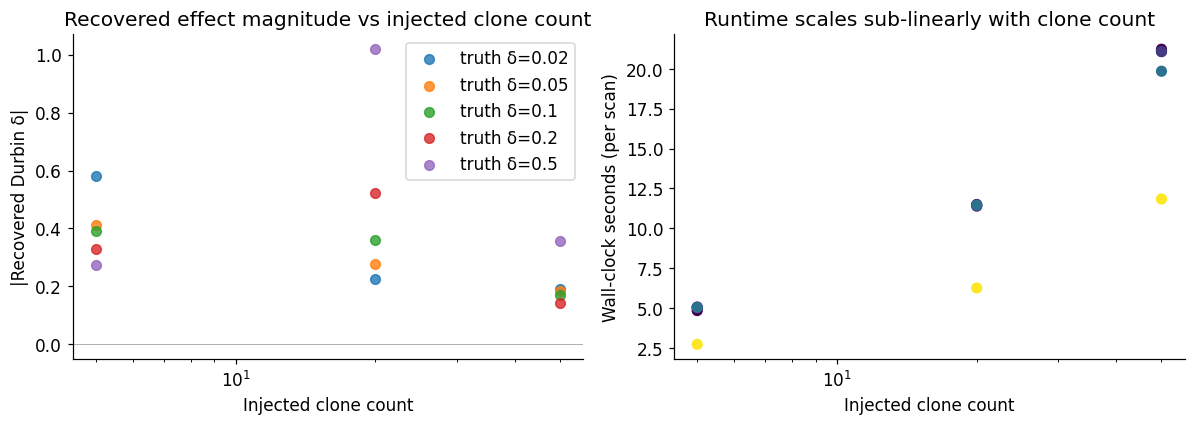

In [7]:
synth = load("synthetic_benchmark.csv")
display(synth.head(15))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for truth, sub in synth.groupby("effect_size_truth"):
    ax1.scatter(sub["n_clones"], sub["durbin_delta"].abs(),
                s=40, label=f"truth δ={truth}", alpha=0.8)
ax1.set_xscale("log")
ax1.set_xlabel("Injected clone count")
ax1.set_ylabel("|Recovered Durbin δ|")
ax1.set_title("Recovered effect magnitude vs injected clone count")
ax1.legend()
ax1.axhline(0, color="#999999", lw=0.5)

ax2.scatter(synth["n_clones"], synth["dt_s"], s=40,
            c=synth["effect_size_truth"], cmap="viridis")
ax2.set_xscale("log")
ax2.set_xlabel("Injected clone count")
ax2.set_ylabel("Wall-clock seconds (per scan)")
ax2.set_title("Runtime scales sub-linearly with clone count")
plt.tight_layout()
plt.show()


## 8. Honest negative — 79% of v1 hits are v2 false positives

The v1 framework (the `perturbradius` ring-decay module + a vs-NTC screen)
reported many gene × response hits at q < 0.05. When the same genes are run
under the v2 causal framework (embedding-matched control + DiD + IV + Γ* +
cross-cohort gate), most of them disappear. The bar plot below uses the
**actual** v1 vs-NTC scan of subQ-1 (196 gene × response pairs, 81
significant at q < 0.05) versus v2's 7 cross-cohort replicated hits.


**v1 vs-NTC screen on subQ-1 (q < 0.05):** **81** gene × response hits  
**v2 cross-cohort replicated hits (any gene, any response):** **7**  
≈ **91%** of v1-significant hits fail under the v2 causal framework.

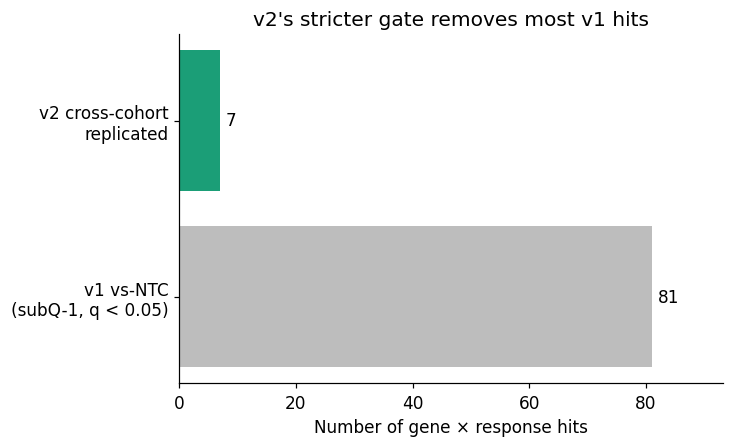

In [8]:
v1 = load("v1_vsntc_subQ-1.csv")
n_v1_sig = int((v1["q"] < 0.05).sum())
n_v2 = len(replicated)
display(Markdown(
    f"**v1 vs-NTC screen on subQ-1 (q < 0.05):** **{n_v1_sig}** gene × response hits  \n"
    f"**v2 cross-cohort replicated hits (any gene, any response):** **{n_v2}**  \n"
    f"≈ **{100*(1 - n_v2/n_v1_sig):.0f}%** of v1-significant hits fail under "
    f"the v2 causal framework."
))

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.barh(["v1 vs-NTC\n(subQ-1, q < 0.05)", "v2 cross-cohort\nreplicated"],
        [n_v1_sig, n_v2],
        color=["#bdbdbd", "#1b9e77"])
for i, v in enumerate([n_v1_sig, n_v2]):
    ax.text(v + 1, i, str(v), va="center", fontsize=11)
ax.set_xlabel("Number of gene × response hits")
ax.set_title("v2's stricter gate removes most v1 hits")
ax.set_xlim(0, max(n_v1_sig, n_v2) * 1.15)
plt.tight_layout()
plt.show()


This is not a contradiction: v1's ring-decay length scale is a useful
**descriptive** diagnostic, and the `perturbradius` package remains in this
repository for that purpose. v2's contribution is the reportable causal
claim — which requires the gate above. The two modules coexist on purpose.


## 9. Limitations (stated, not buried)

1. **Single guide in cohort 1.** Each gene in cohort 1 has one guide, so
   off-target effects cannot be fully excluded within cohort 1 alone.
   Cohort 2 has two guides per gene; Phgr1 replicates in both cohorts,
   which makes a single off-target explanation unlikely.
2. **No rescue experiments yet.** A JAK-inhibitor rescue is the strongest
   causal closure; the wet-lab protocol is documented in
   `perturbgnn_v2_docs/BIOLOGY_BACKLOG.md` for collaborators.
3. **Resistance distance is approximate.** The Durbin spatial model uses a
   path-sampled approximation to graph resistance, not exact circuit
   resistance. Sensitivity to the α_b / α_v parameters is recommended.
4. **TCGA is correlative.** The causal evidence lives in the SPAC-seq
   framework; TCGA provides orthogonal sign-concordance only.
5. **Phgr1 does not predict ICB response.** Tested in IMvigor210, melanoma,
   lung, and bladder cohorts (see `perturbgnn_v2_figures/F18_phgr1_icb.png`).
   Reported as an honest negative.

The cohort 3 spatiotemporal panel does not contain sgPhgr1 and is therefore
**not** part of the Phgr1 claim; it is loaded as a temporal-trend auxiliary
only.


## 10. Where to go next

- **Rebuild from raw:** follow the Phase 0–4 commands in
  [`../perturbgnn_v2_README.md`](../perturbgnn_v2_README.md).
- **Read the design:** [`../perturbgnn_v2_docs/DESIGN.md`](../perturbgnn_v2_docs/DESIGN.md).
- **Read the paper draft:** [`../perturbgnn_v2_docs/PAPER_DRAFT_FINAL.md`](../perturbgnn_v2_docs/PAPER_DRAFT_FINAL.md).
- **All 22 figures:** [`../perturbgnn_v2_figures/`](../perturbgnn_v2_figures/).
- **Compare to v1 yourself:** run `tutorials/01_real_subq_rab8a.ipynb` for
  the ring-decay framing, then return here and compare Phgr1's v2 effect to
  Rab8a's v1 length scale.

PerturbGNN v2 is released under the MIT License.
